## Import libraries

In [23]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

sys.path.insert(0, os.path.abspath('..'))   # so max_heap.py is importable
from max_heap import MaxHeap, euclidean_distance

# Load data

In [24]:
df = pd.read_csv('../data/cleaned/chicago_crimes_cleaned.csv')

In [9]:
df.shape

(7897622, 26)

In [10]:
df[df['date']=='2025-12-29'].tail(1)
# Mondays encoded as day_of_week = 0.

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,updated_on,x_coordinate,y_coordinate,latitude,longitude,time,month,day,day_of_week,hour
7896598,14069151,JJ538729,2025-12-29,054XX S FAIRFIELD AVE,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,RESIDENCE - YARD (FRONT / BACK),True,False,...,2026-03-14T15:41:39.000,1158967.0,1868427.0,41.794691,-87.692606,23:56:00,12,29,0,23


# Encoding cyclical date/time variables

In [11]:
# Convert time to decimal hours: hour + minute/60 + second/3600
td = pd.to_timedelta(df['time'].astype(str))
df['time_decimal'] = td.dt.seconds / 3600

# Convert time to cyclical (using sin)
df['time_cyclical'] = np.sin(2 * np.pi * df['time_decimal'] / 24)


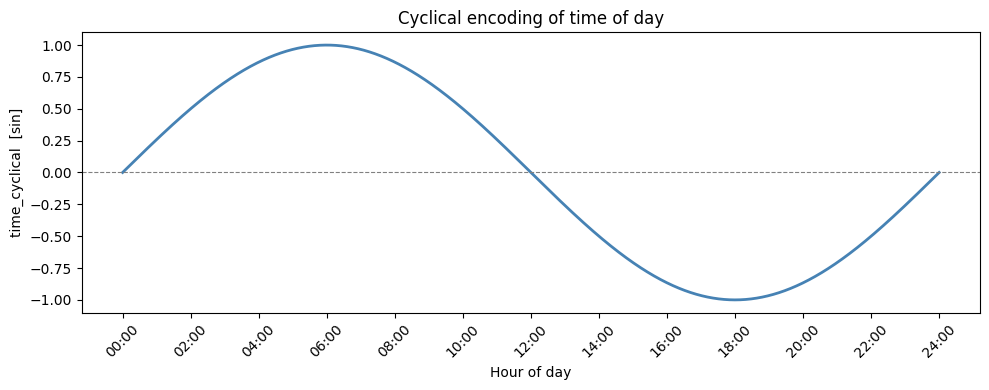

In [12]:
# Plot the sine encoding: x = hour of day, y = time_cyclical
time_mapping = (df[['time_decimal', 'time_cyclical']]
                .drop_duplicates()
                .sort_values('time_decimal'))

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(time_mapping['time_decimal'], time_mapping['time_cyclical'],
        color='steelblue', linewidth=2)

ax.set_xlabel('Hour of day')
ax.set_ylabel('time_cyclical  [sin]')
ax.set_title('Cyclical encoding of time of day')
ax.set_xticks(range(0, 25, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 25, 2)], rotation=45)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()


In [13]:
# Convert date to decimal: (month - 1) + (day - 1) / days_in_month
# dt.days_in_month accounts for leap years automatically (e.g. Feb = 28 or 29)

df['date'] = pd.to_datetime(df['date'])

df['date_decimal'] = (
    (df['date'].dt.month - 1) +
    (df['date'].dt.day - 1) / df['date'].dt.days_in_month
)

# Convert date to cyclical (using sin)
df['date_cyclical'] = np.sin(2 * np.pi * df['date_decimal'] / 12)

In [14]:
# Convert day of the week to cyclical

df['dow_cyclical'] = np.sin(2 * np.pi * df['day_of_week'] / 6)

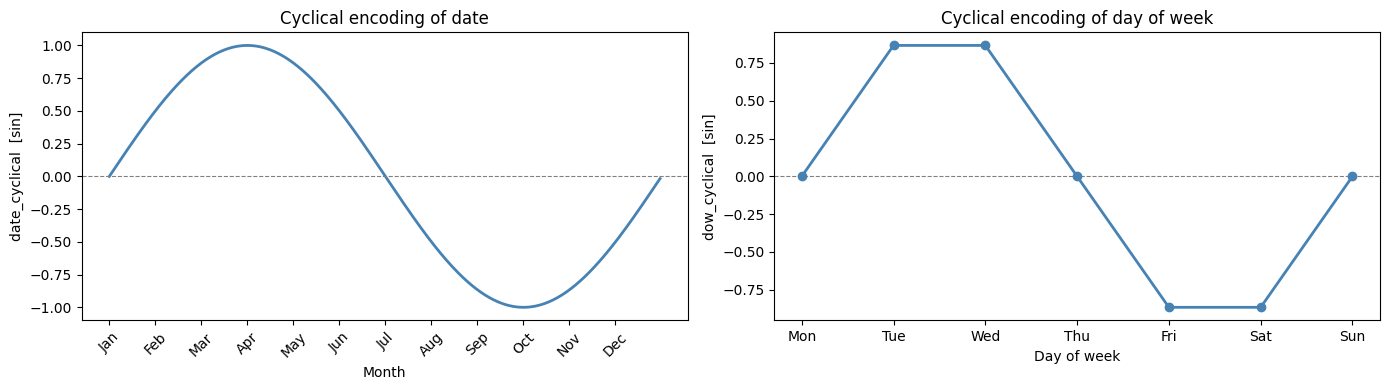

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── date_cyclical ─────────────────────────────────────────────────────────────
date_mapping = (df[['date_decimal', 'date_cyclical']]
                .drop_duplicates()
                .sort_values('date_decimal'))

axes[0].plot(date_mapping['date_decimal'], date_mapping['date_cyclical'],
             color='steelblue', linewidth=2)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('date_cyclical  [sin]')
axes[0].set_title('Cyclical encoding of date')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')

# ── dow_cyclical ──────────────────────────────────────────────────────────────
dow_mapping = (df[['day_of_week', 'dow_cyclical']]
               .drop_duplicates()
               .sort_values('day_of_week'))

axes[1].plot(dow_mapping['day_of_week'], dow_mapping['dow_cyclical'],
             color='steelblue', linewidth=2)
axes[1].scatter(dow_mapping['day_of_week'], dow_mapping['dow_cyclical'],
                color='steelblue', zorder=5)
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('dow_cyclical  [sin]')
axes[1].set_title('Cyclical encoding of day of week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()


# Some graphs

In [16]:
## LOOK AT THIS:

# --- Hello -----------------------
total_cases_per_district_per_year = df.groupby(['district', 'year']).agg(total_cases = ('case_number', 'nunique'))

arrest_in_case = df.groupby('case_number').agg(arrests = ('arrest', 'sum'))

columns_of_interest=['year', 'district', 'case_number']
df_cols = df[columns_of_interest].drop_duplicates()

df_graph1 = pd.merge(df_cols, arrest_in_case, on='case_number', how='left')
df_graph1['had_arrest'] = np.where(
    df_graph1['arrests'] > 0, 1, 0)


In [17]:
# --- Checking if it works:

df_graph1.sort_values(by=['year', 'district', 'case_number'])

# It did :)

,year,district,case_number,arrests,had_arrest
73928,2002,1.0,G128688,1,1
23281,2002,1.0,G760587,1,1
23225,2002,1.0,G760590,1,1
147321,2002,1.0,HH000000,0,0
207158,2002,1.0,HH000191,1,1
...,...,...,...,...,...
7700352,2025,31.0,JJ172679,1,1
7721331,2025,31.0,JJ213829,0,0
7742317,2025,31.0,JJ252525,0,0
7746340,2025,31.0,JJ260308,1,1


In [18]:
## Final table

df_graph1 = df_graph1.groupby(['year','district']).agg(total_cases = ('case_number','count'),
                                                       total_atleastonearrest = ('had_arrest', 'sum'))
df_graph1['had_arrest_rate'] = df_graph1['total_atleastonearrest'] / df_graph1['total_cases']
df_graph1 = df_graph1.reset_index()

I want to graph, for each district, the proportion of cases in which at least one arrest ocurred per year:

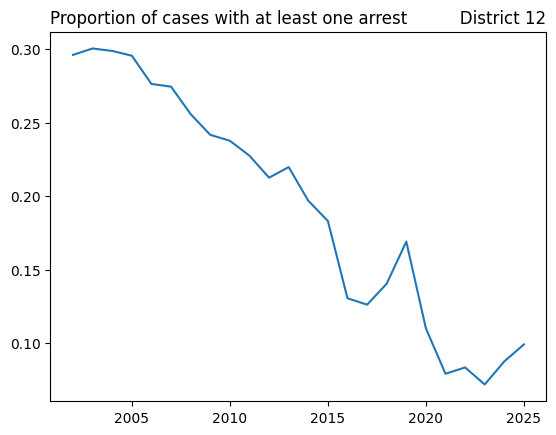

In [19]:
# As it is now, you need to change the district manually:

plt.plot(df_graph1['year'][df_graph1['district']==12], df_graph1['had_arrest_rate'][df_graph1['district']==12])
plt.title('Proportion of cases with at least one arrest\
          District 12')
plt.show()

Put differently, I now graph, for each year, the proportion of cases that involved at least one arrest per district.

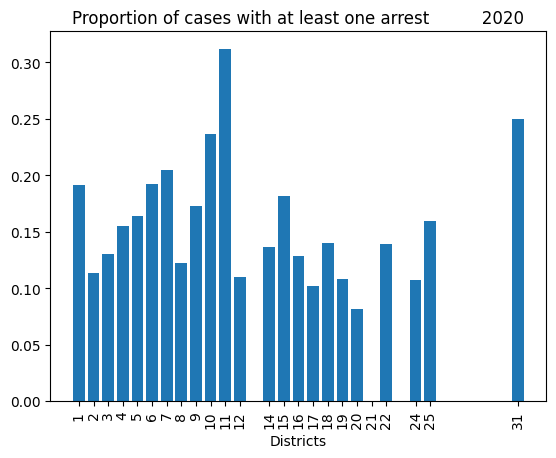

In [20]:
# As it is now, you need to change the year manually:

plt.bar(df_graph1['district'][df_graph1['year']==2020], df_graph1['had_arrest_rate'][df_graph1['year']==2020])
plt.title('Proportion of cases with at least one arrest\
          2020')
plt.xlabel('Districts')
plt.xticks(ticks = df_graph1['district'].unique(), rotation = 90)
plt.show()

# KNN + Ridge Regression — Predicting Arrest

In [21]:
# ── target ────────────────────────────────────────────────────────────────────
df['arrest_int'] = df['arrest'].astype(int)

# ── other numeric features ────────────────────────────────────────────────────
df['domestic_int'] = df['domestic'].astype(int)

FEATURES = [
    'time_cyclical',
    'date_cyclical',
    'dow_cyclical',
    'domestic_int',
    'district',
    'x_coordinate',
    'y_coordinate',
]
TARGET = 'arrest_int'

model_df = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)
print(model_df.shape)
model_df.head()

(7897575, 8)


,time_cyclical,date_cyclical,dow_cyclical,domestic_int,district,x_coordinate,y_coordinate,arrest_int
0,0.0,0.0,0.866025,0,24.0,1157181.0,1941908.0,0
1,0.0,0.0,0.866025,0,4.0,1192988.0,1848862.0,0
2,0.0,0.0,0.866025,0,19.0,1163946.0,1931450.0,0
3,0.0,0.0,0.866025,0,25.0,1138221.0,1918236.0,0
4,0.0,0.0,0.866025,0,8.0,1149846.0,1860270.0,0


In [22]:
from sklearn.model_selection import train_test_split

# Use a small sample so KNN is tractable without vectorised distance
SAMPLE_SIZE = 20_000
sample = model_df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

X = sample[FEATURES].values
y = sample[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — critical for Euclidean distance (KNN is distance-sensitive)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Arrest rate — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Train: (16000, 7), Test: (4000, 7)
Arrest rate — train: 0.248, test: 0.248


In [23]:
def knn_ridge_predict(X_train, y_train, query, k, alpha=1.0):
    """
    Predict a single query point using local ridge regression.

    1. MaxHeap finds the k nearest neighbours in O(n log k).
    2. Ridge regression is fitted on those k points only.
    3. Returns a raw score (not thresholded).
    """
    heap = MaxHeap(capacity=k)

    for i, x in enumerate(X_train):
        dist = euclidean_distance(x.tolist(), query.tolist())
        heap.add(dist, float(i))          # store row index as target

    # Retrieve the k neighbours
    neighbour_indices = [int(target) for _, target in heap.get_all()]
    X_local = X_train[neighbour_indices]
    y_local = y_train[neighbour_indices]

    # Fit ridge on the local neighbourhood
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_local, y_local)

    return ridge.predict(query.reshape(1, -1))[0]


# ── Run on the test set ────────────────────────────────────────────────────────
K     = 30      # number of neighbours
ALPHA = 1.0     # ridge regularisation strength

raw_scores = np.array([
    knn_ridge_predict(X_train_s, y_train, q, k=K, alpha=ALPHA)
    for q in X_test_s
])

# Threshold at 0.5 for binary classification
y_pred = (raw_scores >= 0.5).astype(int)

NameError: name 'MaxHeap' is not defined

In [ ]:
print(classification_report(y_test, y_pred, target_names=['No arrest', 'Arrest']))
print(f"ROC-AUC: {roc_auc_score(y_test, raw_scores):.4f}")

              precision    recall  f1-score   support

   No arrest       0.76      0.97      0.85      2994
      Arrest       0.45      0.08      0.13      1006

    accuracy                           0.74      4000
   macro avg       0.60      0.52      0.49      4000
weighted avg       0.68      0.74      0.67      4000

ROC-AUC: 0.5899


# Grace's addition
**Collapsed df s.t. each row is an incident, added three new columns: 1) at least one arrested, 2) how many people involved, 3) probability of arrest for given incident**

In [25]:
# --- Before collapsing: count people involved per incident ---
people_per_incident = df.groupby('case_number').size().rename('people_involved')

# --- Collapse: one row per incident ---
# For most columns, take the first value (they should be the same across rows of the same incident)
# For 'arrest', take max — True if ANY person was arrested (your binary variable)
incident_df = df.groupby('case_number').agg(
    date=('date', 'first'),
    block=('block', 'first'),
    primary_type=('primary_type', 'first'),
    description=('description', 'first'),
    location_description=('location_description', 'first'),
    domestic=('domestic', 'first'),
    district=('district', 'first'),
    x_coordinate=('x_coordinate', 'first'),
    y_coordinate=('y_coordinate', 'first'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
    time=('time', 'first'),
    month=('month', 'first'),
    day=('day', 'first'),
    day_of_week=('day_of_week', 'first'),
    hour=('hour', 'first'),
    at_least_one_arrested=('arrest', 'max'),   # True if any row had arrest=True
).reset_index()

# --- Attach people_involved ---
incident_df = incident_df.merge(people_per_incident, on='case_number')

print(f"Original rows:  {len(df)}")
print(f"Collapsed rows: {len(incident_df)}")
incident_df.head()

Original rows:  7898407
Collapsed rows: 7897823


,case_number,date,block,primary_type,description,location_description,domestic,district,x_coordinate,y_coordinate,latitude,longitude,time,month,day,day_of_week,hour,at_least_one_arrested,people_involved
0,04X245238,2004-12-13,006XX N RIDGEWAY AVE,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,False,11.0,1151273.0,1903996.0,41.892451,-87.719888,21:15:00,12,13,0,21,True,1
1,07C115980,2006-03-31,026XX N NARRAGANSETT AVE,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,25.0,1133296.0,1916864.0,41.928096,-87.785610,09:15:00,3,31,4,9,False,1
2,07HN36467,2007-05-25,022XX N LA CROSSE AVE,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,False,25.0,1143697.0,1914371.0,41.921066,-87.747452,14:51:00,5,25,4,14,True,1
3,121135,2005-01-12,031XX W CERMAK RD,THEFT,$500 AND UNDER,STREET,False,10.0,1155794.0,1889210.0,41.851786,-87.703683,09:00:00,1,12,2,9,False,1
4,186982,2003-02-16,052XX W PARKER AVE,MOTOR VEHICLE THEFT,"TRUCK, BUS, MOTOR HOME",STREET,False,25.0,1140987.0,1917784.0,41.930482,-87.757325,14:38:36,2,16,6,14,False,1


In [26]:
# --- Rebuild cyclical features on incident_df ---
incident_df['time_decimal'] = pd.to_timedelta(incident_df['time'].astype(str)).dt.seconds / 3600
incident_df['time_cyclical'] = np.sin(2 * np.pi * incident_df['time_decimal'] / 24)
incident_df['date_cyclical'] = np.sin(2 * np.pi * pd.to_datetime(incident_df['date']).dt.dayofyear / 365)
incident_df['dow_cyclical']  = np.sin(2 * np.pi * incident_df['day_of_week'] / 7)
incident_df['domestic_int']  = incident_df['domestic'].astype(int)

FEATURES = [
    'time_cyclical', 'date_cyclical', 'dow_cyclical',
    'domestic_int', 'district', 'x_coordinate', 'y_coordinate'
]

# --- Drop NaNs from incident_df in place, keeping index aligned ---
incident_df = incident_df.dropna(subset=FEATURES).reset_index(drop=True)


In [28]:
incident_df = incident_df[incident_df['people_involved'] == 1]

In [31]:
incident_df['arrest'] = incident_df['at_least_one_arrested'].astype(int)

In [35]:
incident_df['primary_type'].value_counts()

primary_type
THEFT                                1680400
BATTERY                              1444201
CRIMINAL DAMAGE                       903467
NARCOTICS                             701921
ASSAULT                               535124
OTHER OFFENSE                         494635
BURGLARY                              420076
MOTOR VEHICLE THEFT                   403978
DECEPTIVE PRACTICE                    354950
ROBBERY                               295775
CRIMINAL TRESPASS                     213584
WEAPONS VIOLATION                     120989
PROSTITUTION                           63771
OFFENSE INVOLVING CHILDREN             54123
PUBLIC PEACE VIOLATION                 51992
SEX OFFENSE                            30238
CRIM SEXUAL ASSAULT                    24045
INTERFERENCE WITH PUBLIC OFFICER       19921
LIQUOR LAW VIOLATION                   13676
GAMBLING                               13635
ARSON                                  13395
HOMICIDE                               123

## KNN algorithm

In [37]:
knn_df = incident_df[['primary_type', 'latitude', 'longitude', 'time_cyclical',\
                      'dow_cyclical', 'date_cyclical', 'month', 'day', 'day_of_week',\
                      'hour', 'arrest']]

In [38]:
knn_df.head()

,primary_type,latitude,longitude,time_cyclical,dow_cyclical,date_cyclical,month,day,day_of_week,hour,arrest
0,NARCOTICS,41.892451,-87.719888,-0.659346,0.000000,-0.288482,12,13,0,21,1
1,BURGLARY,41.928096,-87.785610,0.659346,-0.433884,0.999769,3,31,4,9,0
2,NARCOTICS,41.921066,-87.747452,-0.678801,-0.433884,0.601624,5,25,4,14,1
3,THEFT,41.851786,-87.703683,0.707107,0.974928,0.205104,1,12,2,9,0
4,MOTOR VEHICLE THEFT,41.930482,-87.757325,-0.638096,-0.781831,0.723644,2,16,6,14,0
